In [2]:
eda_analysis.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


NameError: name 'eda_analysis' is not defined

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
print("Detective tools ready!")


Detective tools ready!


In [6]:
import os
os.listdir('../data')

['Data Legend.txt',
 'ethiopia.csv',
 'kenya.csv',
 'nigeria.csv',
 'sudan.csv',
 'tanzania.csv']

In [8]:
import pandas as pd
#load the Ethiopia dataset
df = pd.read_csv('../data/ethiopia.csv') 
# show the firs 5 raws to see what columns we have df.head()

In [12]:
# This lists every column and tells you how many empty (NaN) cells are in each df.isnull().sum()

In [13]:
# This lists every column and tells you how many empty (NaN) cells are in each
df.isnull().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

In [14]:
# This shows the range of your data 
df[['T2M', 'RH2M', 'WS2M', 'PRECTOTCORR']].DESCRIBE().loc[['min', 'max']]

AttributeError: 'DataFrame' object has no attribute 'DESCRIBE'

In [15]:
# Use lowercase .describe()
df[['T2M', 'RH2M', 'WS2M', 'PRECTOTCORR']].describe().loc[['min', 'max']]


,T2M,RH2M,WS2M,PRECTOTCORR
min,10.03,14.42,0.46,0.0
max,21.53,91.93,4.13,82.3


In [16]:
# This creates a 'Date' column using YEAR and the Day of the Year (DOY)
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str), format='%Y%j')

# Show the new column to make sure it worked
df[['YEAR', 'DOY', 'Date']].head()


,YEAR,DOY,Date
0,2015,1,2015-01-01
1,2015,2,2015-01-02
2,2015,3,2015-01-03
3,2015,4,2015-01-04
4,2015,5,2015-01-05


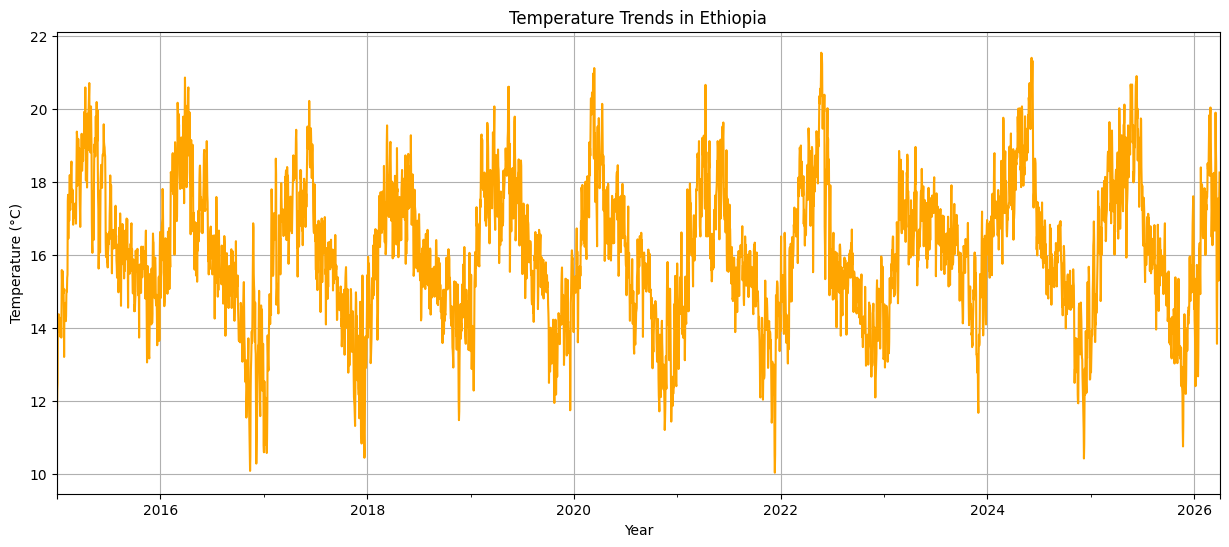

In [17]:
import matplotlib.pyplot as plt

# Set the Date as the index just for this plot
df.set_index('Date')['T2M'].plot(figsize=(15, 6), color='orange')

# Add labels so it looks professional for your report
plt.title('Temperature Trends in Ethiopia')
plt.ylabel('Temperature (°C)')
plt.xlabel('Year')
plt.grid(True)
plt.show()


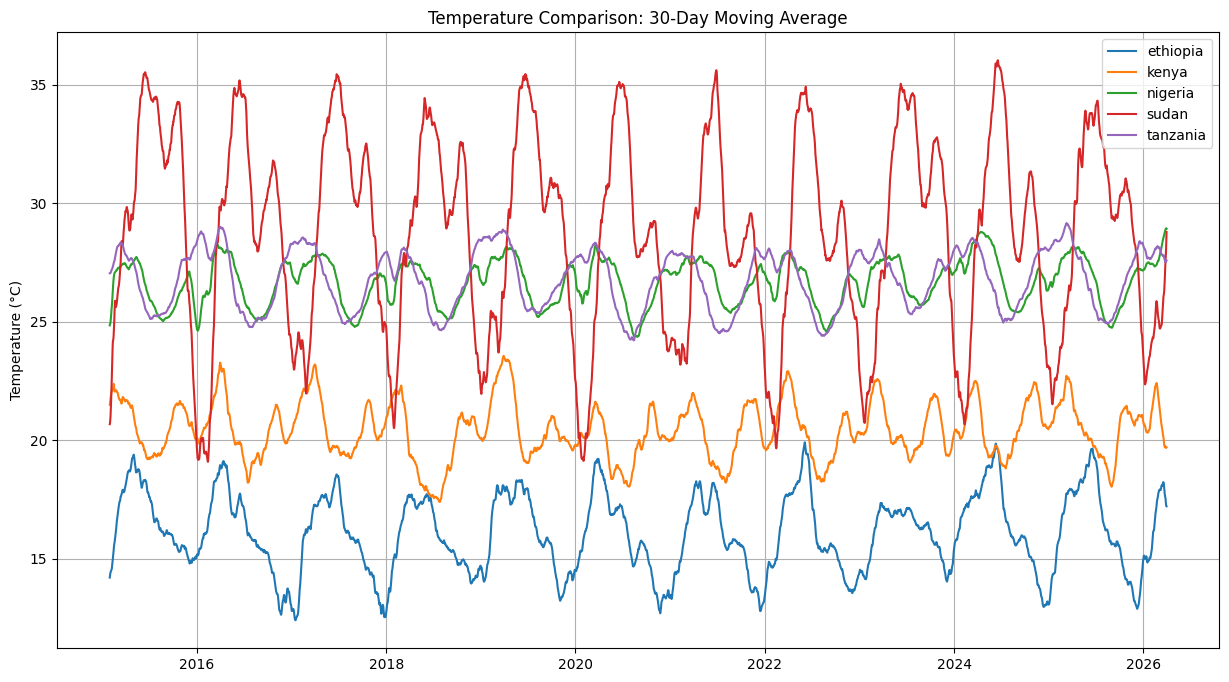

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# List of your files
files = ['ethiopia.csv', 'kenya.csv', 'nigeria.csv', 'sudan.csv', 'tanzania.csv']

plt.figure(figsize=(15, 8))

for file in files:
    # Load each file
    temp_df = pd.read_csv(f'../data/{file}')
    
    # Create the Date column just like we did for Ethiopia
    temp_df['Date'] = pd.to_datetime(temp_df['YEAR'].astype(str) + temp_df['DOY'].astype(str), format='%Y%j')
    
    # Plot Temperature (T2M) for this country
    # We use a rolling mean (30 days) to make the lines smoother and easier to read
    plt.plot(temp_df['Date'], temp_df['T2M'].rolling(30).mean(), label=file.replace('.csv', ''))

plt.title('Temperature Comparison: 30-Day Moving Average')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()


In [19]:
# Create an empty list to store summaries
summaries = []

for file in files:
    temp_df = pd.read_csv(f'../data/{file}')
    
    # Calculate the average for key columns
    avg_temp = temp_df['T2M'].mean()
    avg_hum = temp_df['RH2M'].mean()
    avg_wind = temp_df['WS2M'].mean()
    
    # Store the results in a dictionary
    summaries.append({
        'Country': file.replace('.csv', '').capitalize(),
        'Avg Temp (°C)': round(avg_temp, 2),
        'Avg Humidity (%)': round(avg_hum, 2),
        'Avg Wind Speed (m/s)': round(avg_wind, 2)
    })

# Turn the list into a clean Table (DataFrame)
summary_table = pd.DataFrame(summaries)
summary_table


,Country,Avg Temp (°C),Avg Humidity (%),Avg Wind Speed (m/s)
0,Ethiopia,16.07,68.41,1.98
1,Kenya,20.43,65.85,3.06
2,Nigeria,26.66,85.24,2.22
3,Sudan,28.76,31.36,3.48
4,Tanzania,26.80,77.13,4.11


In [20]:
# Select only the main weather columns for correlation
columns_to_check = ['T2M', 'RH2M', 'WS2M', 'PRECTOTCORR', 'PS']
correlation_matrix = df[columns_to_check].corr()

# Display the matrix
correlation_matrix.style.background_gradient(cmap='coolwarm')


,T2M,RH2M,WS2M,PRECTOTCORR,PS
T2M,1.000000,-0.194146,-0.069825,0.009186,-0.184556
RH2M,-0.194146,1.000000,-0.444068,0.501347,-0.047753
WS2M,-0.069825,-0.444068,1.000000,-0.390109,0.170016
PRECTOTCORR,0.009186,0.501347,-0.390109,1.000000,-0.096233
PS,-0.184556,-0.047753,0.170016,-0.096233,1.000000


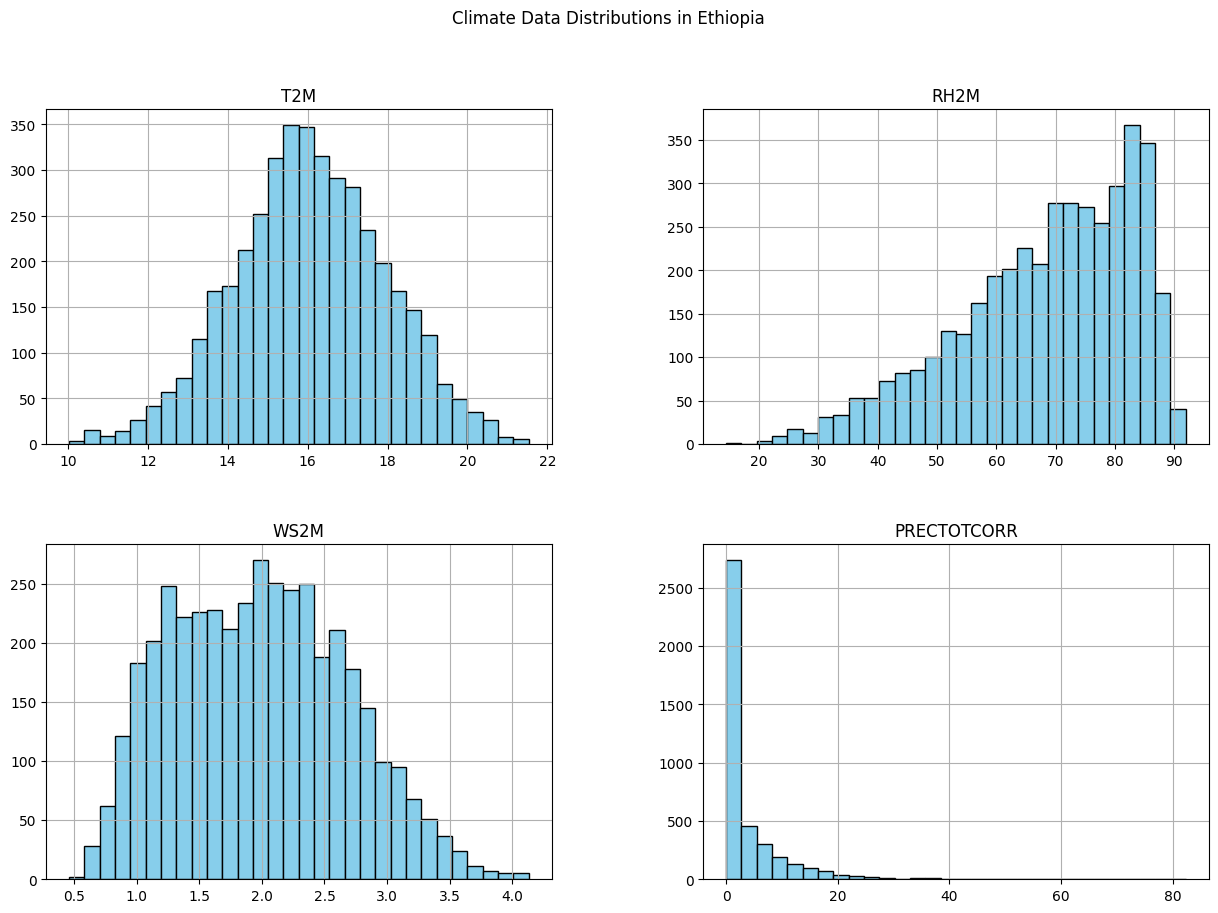

In [21]:
# This creates a grid of charts to show the 'shape' of your data
df[['T2M', 'RH2M', 'WS2M', 'PRECTOTCORR']].hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')

plt.suptitle('Climate Data Distributions in Ethiopia')
plt.show()


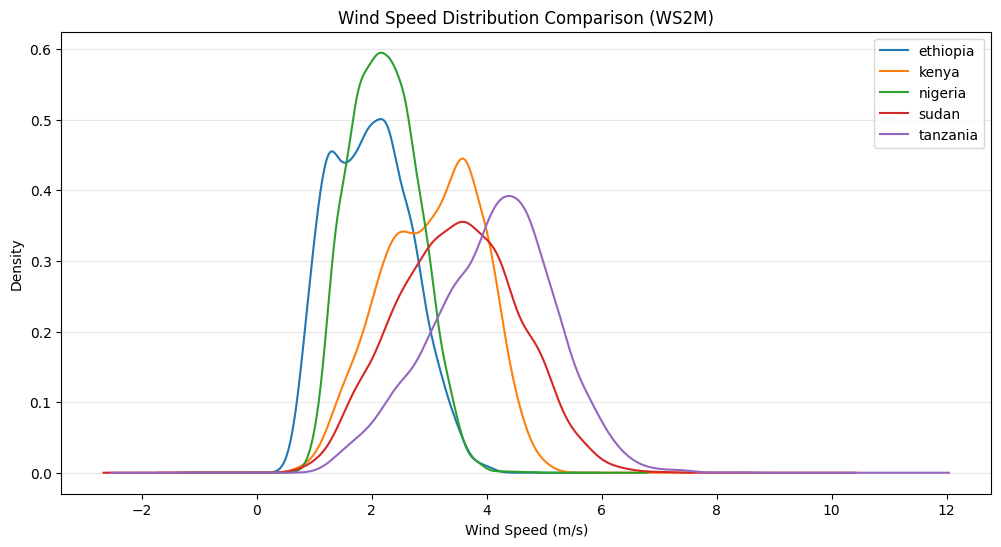

In [23]:
plt.figure(figsize=(12, 6))

for file in files:
    temp_df = pd.read_csv(f'../data/{file}')
    # We use a KDE (Kernel Density Estimate) to show the "shape" of the wind
    temp_df['WS2M'].plot(kind='kde', label=file.replace('.csv', ''))

plt.title('Wind Speed Distribution Comparison (WS2M)')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show() 


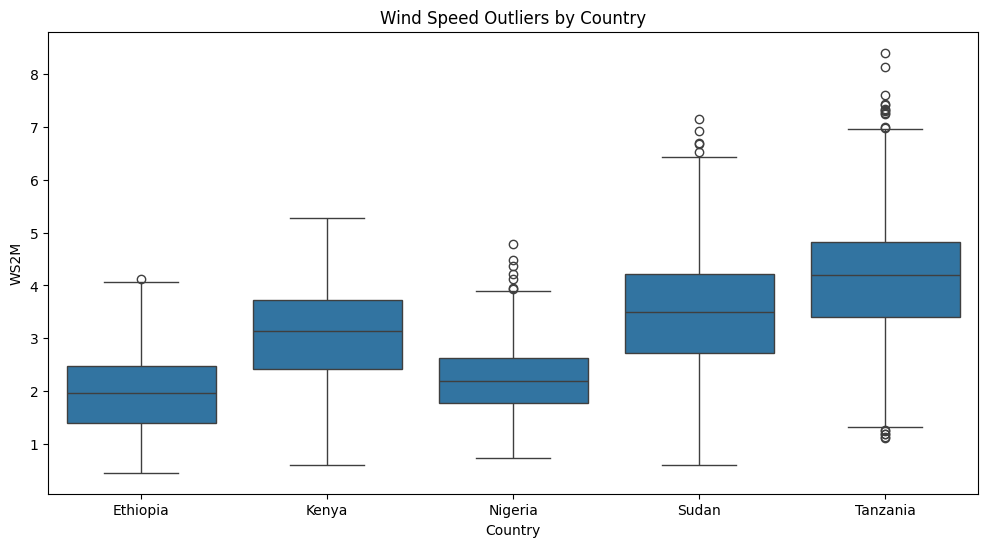

In [24]:
import seaborn as sns

# We will use Seaborn to make a clean comparison Box Plot
all_data = []
for file in files:
    temp_df = pd.read_csv(f'../data/{file}')
    temp_df['Country'] = file.replace('.csv', '').capitalize()
    all_data.append(temp_df)

df_combined = pd.concat(all_data)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Country', y='WS2M', data=df_combined)
plt.title('Wind Speed Outliers by Country')
plt.show()


In [25]:
import pandas as pd

# List of all your country files
files = ['ethiopia.csv', 'kenya.csv', 'nigeria.csv', 'sudan.csv', 'tanzania.csv']
all_summaries = []

for file in files:
    # 1. Load data
    temp_df = pd.read_csv(f'../data/{file}')
    
    # 2. Add Country name for identification
    country_name = file.replace('.csv', '').capitalize()
    
    # 3. Calculate Key Performance Indicators (KPIs)
    summary = {
        'Country': country_name,
        'Avg Solar (GHI)': round(temp_df['GHI'].mean() if 'GHI' in temp_df else temp_df.iloc[:, 3].mean(), 2),
        'Max Wind Speed': temp_df['WS2M'].max(),
        'Avg Temp': round(temp_df['T2M'].mean(), 2),
        'Data Quality (Missing %)': (temp_df.isnull().sum().sum() / len(temp_df)) * 100
    }
    all_summaries.append(summary)

# 4. Create the Final Ranking Table
ranking_df = pd.DataFrame(all_summaries).sort_values(by='Avg Solar (GHI)', ascending=False)
ranking_df


,Country,Avg Solar (GHI),Max Wind Speed,Avg Temp,Data Quality (Missing %)
3,Sudan,36.77,7.15,28.76,0.0
4,Tanzania,29.16,8.40,26.80,0.0
2,Nigeria,28.91,4.78,26.66,0.0
1,Kenya,27.84,5.28,20.43,0.0
0,Ethiopia,23.20,4.13,16.07,0.0


In [27]:
git add .
    

SyntaxError: invalid syntax (2817916355.py, line 1)

In [28]:
git add .

SyntaxError: invalid syntax (3827820173.py, line 1)